In [1]:
%load_ext autoreload

In [2]:
%reload_ext autoreload

In [3]:
%autoreload 2

In [4]:
import sys
import os
from pathlib import Path

In [5]:
BASE_PATH = Path(os.path.abspath('')).parent.parent.parent
sys.path.append(str(BASE_PATH))

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np

import matplotlib.pyplot as plt
import scienceplots

%matplotlib inline

# plt.style.use(['science','ieee'])
# plt.style.use(['science','nature'])

In [7]:
portfolio = pd.read_csv('fama_french_100.csv')
portfolio['date'] = pd.to_datetime(portfolio['date']).dt.date
portfolio = portfolio.set_index('date')
portfolio.columns = [c.replace(" ", "") for c in portfolio.columns]
portfolio = (1 + portfolio / 100).cumprod()
portfolio = np.log(portfolio / portfolio.shift(1))
portfolio = portfolio.fillna(0.)
portfolio.head()

,SMALLLoBM,ME1BM2,ME1BM3,ME1BM4,ME1BM5,ME1BM6,ME1BM7,ME1BM8,ME1BM9,SMALLHiBM,...,BIGLoBM,ME10BM2,ME10BM3,ME10BM4,ME10BM5,ME10BM6,ME10BM7,ME10BM8,ME10BM9,BIGHiBM
date,,,,,,,,,,,,,,,,,,,,,
1963-07-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1963-08-01,-0.012529,0.063631,0.039564,-0.021700,0.009290,0.012069,0.015811,0.033458,0.046316,0.050872,...,0.057164,0.050983,0.043899,0.035478,0.039091,0.071499,0.056199,0.118945,0.057711,0.055667
1963-09-01,0.034536,-0.064830,0.015540,0.025070,0.013427,-0.019602,0.009839,-0.024717,-0.029613,-0.002000,...,-0.005062,-0.023653,0.006818,-0.025710,-0.009008,-0.022865,-0.009491,0.041866,-0.035567,-0.098083
1963-10-01,-0.015802,0.081380,0.020900,-0.005108,0.031100,-0.021047,0.007043,0.021480,0.005514,0.008524,...,0.038697,0.080698,0.019944,0.019436,-0.011514,0.017485,-0.011712,0.045158,0.004760,0.007605
1963-11-01,0.010422,-0.078896,-0.026857,-0.041097,-0.020018,-0.015880,-0.019083,-0.012542,-0.013751,-0.017572,...,0.002772,-0.039357,0.026256,-0.011667,-0.027589,0.001063,-0.024331,-0.028811,-0.005994,0.061693


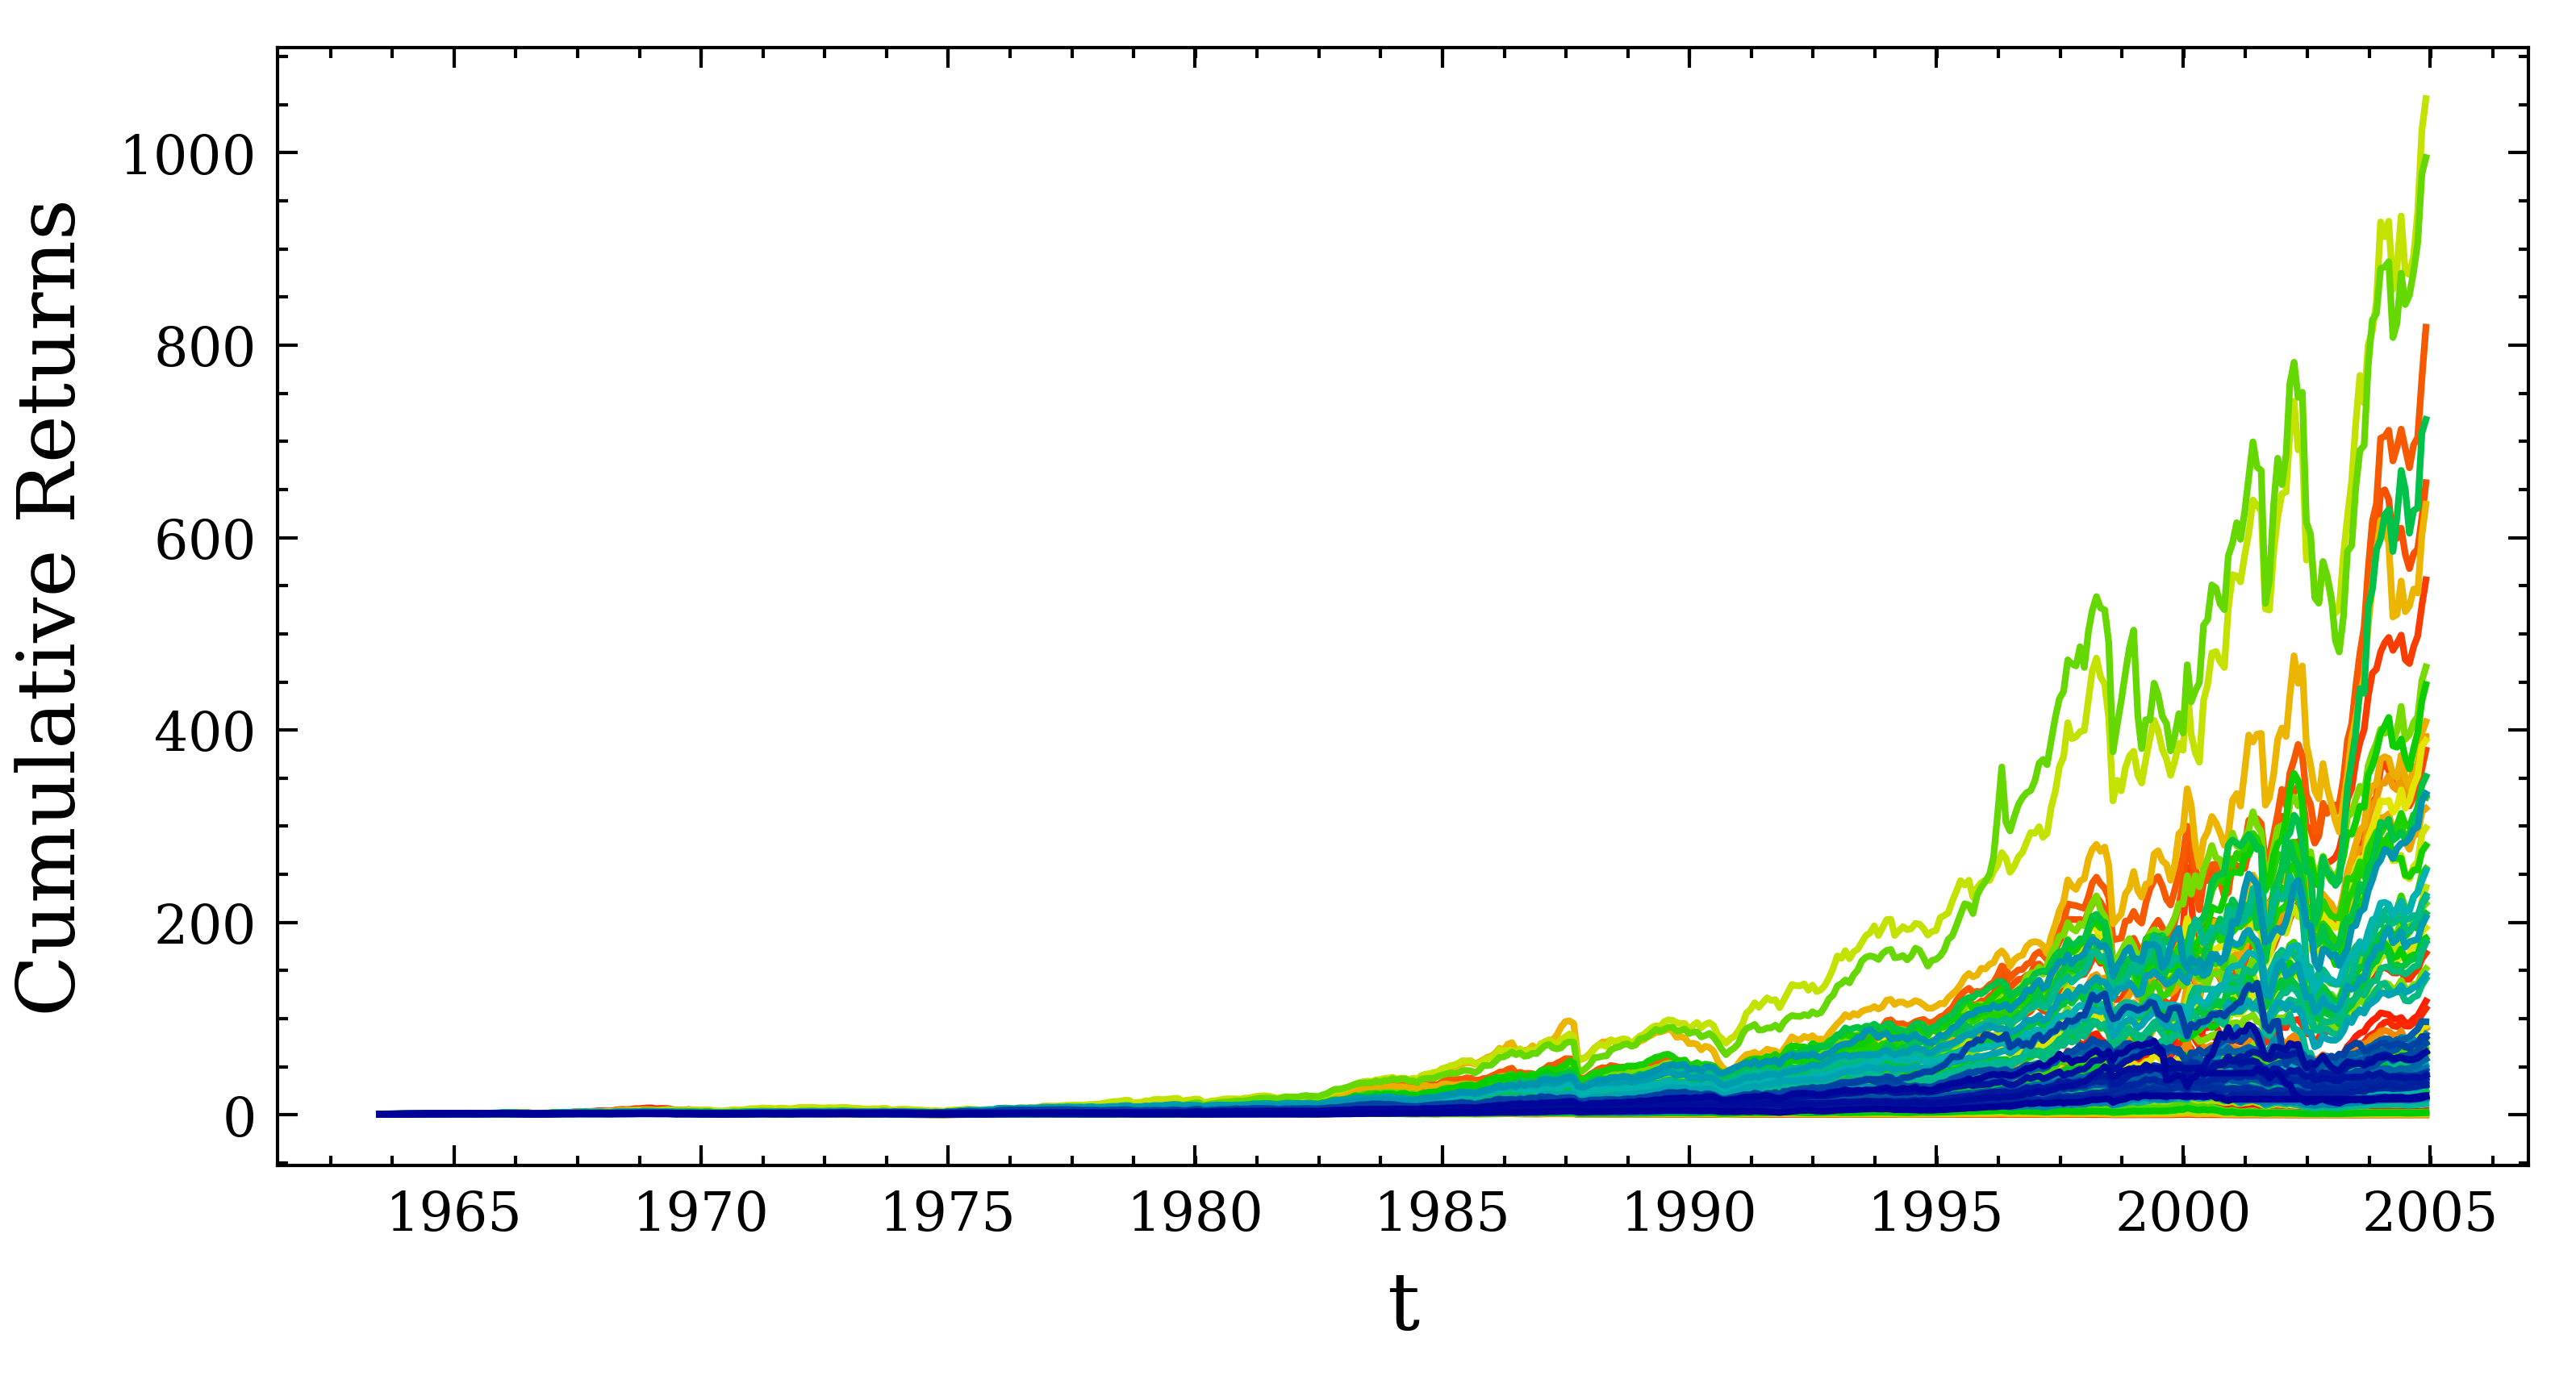

In [8]:
from colour import Color

blue = Color("red", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(portfolio.columns)))

with plt.style.context(['science', 'ieee', 'no-latex']):
    fig, ax = plt.subplots(figsize=(6, 3))
    i = 0
    for col in portfolio.columns:
        plt.plot((portfolio[col] + 1).cumprod(), color=colors[i].rgb, linestyle="-")
        i += 1
    #     plt.legend(portfolio.columns, fontsize=4)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('Cumulative Returns', fontsize=12)
    plt.savefig('0425_ff100_classes.jpg', dpi=600)

In [9]:
from bandits_lib.replay_engines.interface import interpolate_colors

def plot_rewards(obj,                 
                 save_fig: bool = False,
                 figure_name: str = None,
                 oracle: np.ndarray = None,
                 oracle_name: str = "Oracle",
                 personalized_colors: list = None,
                 color_start: str = "#1f77b4",
                 color_end: str = "#ff7f0e"):

    if save_fig and figure_name is None:
        raise ValueError("Please provide a figure name to save the plot.")
    
    # Default Matplotlib blue and orange
    color_vector_size = len(obj.bandit_policies)
    colors = interpolate_colors(color_start, color_end, color_vector_size)
    if personalized_colors is not None:
        colors = personalized_colors
    
    with plt.style.context(['science', 'ieee', 'no-latex']):
        plt.subplots(figsize=(6, 3))
    
        if oracle is not None:
            plt.plot(obj.portfolio.index, np.exp(np.cumsum(oracle)), color='black', linestyle='-', label=oracle_name)
    
        i = 0
        for policy, output in obj.bandit_policies.items():
            plt.plot(obj.portfolio.index, np.exp(np.cumsum(output['mean_reward'])), color=colors[i], linestyle='-', label=policy)
            i += 1
        plt.legend(loc='upper left', fontsize=7)
        plt.xlabel('t', fontsize=10)
        plt.ylabel('Cumulative Returns', fontsize=10)
        if save_fig:
            plt.savefig(figure_name, dpi=600)

In [10]:
def calculate_metrics(log_returns):
    returns = np.exp(log_returns) - 1
    cumulative_returns = np.cumprod(1 + returns) - 1
    daily_returns = np.mean(returns)
    volatility = np.std(returns)
    drawdown = np.min(cumulative_returns - np.maximum.accumulate(cumulative_returns))
    win_rate = np.sum(returns > 0) / len(returns)
    
    # Risk-adjusted ratios
    risk_free_rate = 0.0  # Assuming risk-free rate is zero
    excess_returns = returns - risk_free_rate
    sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns)# * np.sqrt(365)
    downside_deviation = np.std(excess_returns[excess_returns < 0])
    sortino_ratio = np.mean(excess_returns) / downside_deviation
    calmar_ratio = np.mean(excess_returns) / drawdown
    
    return {
        "Cumulative Returns": cumulative_returns[-1],
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": drawdown,
#         "Average Daily Returns": daily_returns,
        "Std. Deviation": volatility,
        # "Win Rate": win_rate,
        # "Sortino Ratio": sortino_ratio,
#         "Calmar Ratio": calmar_ratio
    }

In [11]:
def aggregate_metrics(policies: dict):
    portfolio_history = {}
    index = []
    for policy, output in policies.items():
        metrics_dict = calculate_metrics(output["mean_reward"])
        for k, v in metrics_dict.items():
            if k not in portfolio_history.keys():
                portfolio_history[k] = [v]
            else:
                portfolio_history[k].append(v)
        index.append(policy)
    df = pd.DataFrame(portfolio_history, index=index)
    df = df.sort_values("Cumulative Returns", ascending=False)
    return df

## 4- Investigating Bandit Networks

In [50]:
# portfolio_size = 15
first_time = True

for portfolio_size in [5, 10, 15, 20]:

    bandit_net_policies = {
        f"Two Stage ADTS (mean) | (n={portfolio_size})": {
            "network_name": "BanditNetwork",
            "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
            "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
            "combinatorial_agents": [],
            "agents": [],
            "chosen_superarms": []
        },
        # f"ADTS (mean) + Classical TS | (n={portfolio_size})": {
        #     "network_name": "BanditNetwork",
        #     "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        #     "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
        #     "policy_name": "ThompsonSampling",
        #     "args": {"n_arms": portfolio.shape[1]},
        #     "combinatorial_agents": [],
        #     "agents": [],
        #     "chosen_superarms": []
        # },
        # f"ADTS (mean) + f-DSW TS | (n={portfolio_size})": {
        #     "network_name": "BanditNetwork",
        #     "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        #     "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
        #     "policy_name": "CavenaghiFDSWTS",
        #     "args": {"n_arms": portfolio.shape[1], "gamma": 1.0, "f": "min", "n": 125},
        #     "combinatorial_agents": [],
        #     "agents": [],
        #     "chosen_superarms": []
        # },
        # f"ADTS (mean) + SW UCB | (n={portfolio_size})": {
        #     "network_name": "BanditNetwork",
        #     "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        #     "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
        #     "policy_name": "SlidingWindowUCB1",
        #     "args": {"n_arms": portfolio.shape[1], "w": 30},
        #     "combinatorial_agents": [],
        #     "agents": [],
        #     "chosen_superarms": []
        # },
    }
    from bandits_lib.replay_engines.interface import BanditNetworkBacktestInterface

    temp_backtester = BanditNetworkBacktestInterface(
        bandit_policies=bandit_net_policies,
        portfolio_size=portfolio_size,
        n_simulations=50,
        reward_function="SharpeArm",
        reward_function_args=dict(),
        portfolio=portfolio,
    )
    temp_backtester.run()

    if first_time:
        bandit_backtester = temp_backtester
        first_time = False
    else:
        bandit_backtester.bandit_policies.update(temp_backtester.bandit_policies)

/Users/gfonseca/Desktop/Doutorado - EEC-I/Pesquisa/bandits-lib/venv/lib/python3.9/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice                                   | 0/50 [00:00<?, ?it/s]
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/gfonseca/Desktop/Doutorado - EEC-I/Pesquisa/bandits-lib/venv/lib/python3.9/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/gfonseca/Desktop/Doutorado - EEC-I/Pesquisa/bandits-lib/venv/lib/python3.9/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:24<00:00,  1.69s/it]


In [51]:
blue = Color("orange", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(bandit_backtester.bandit_policies)))

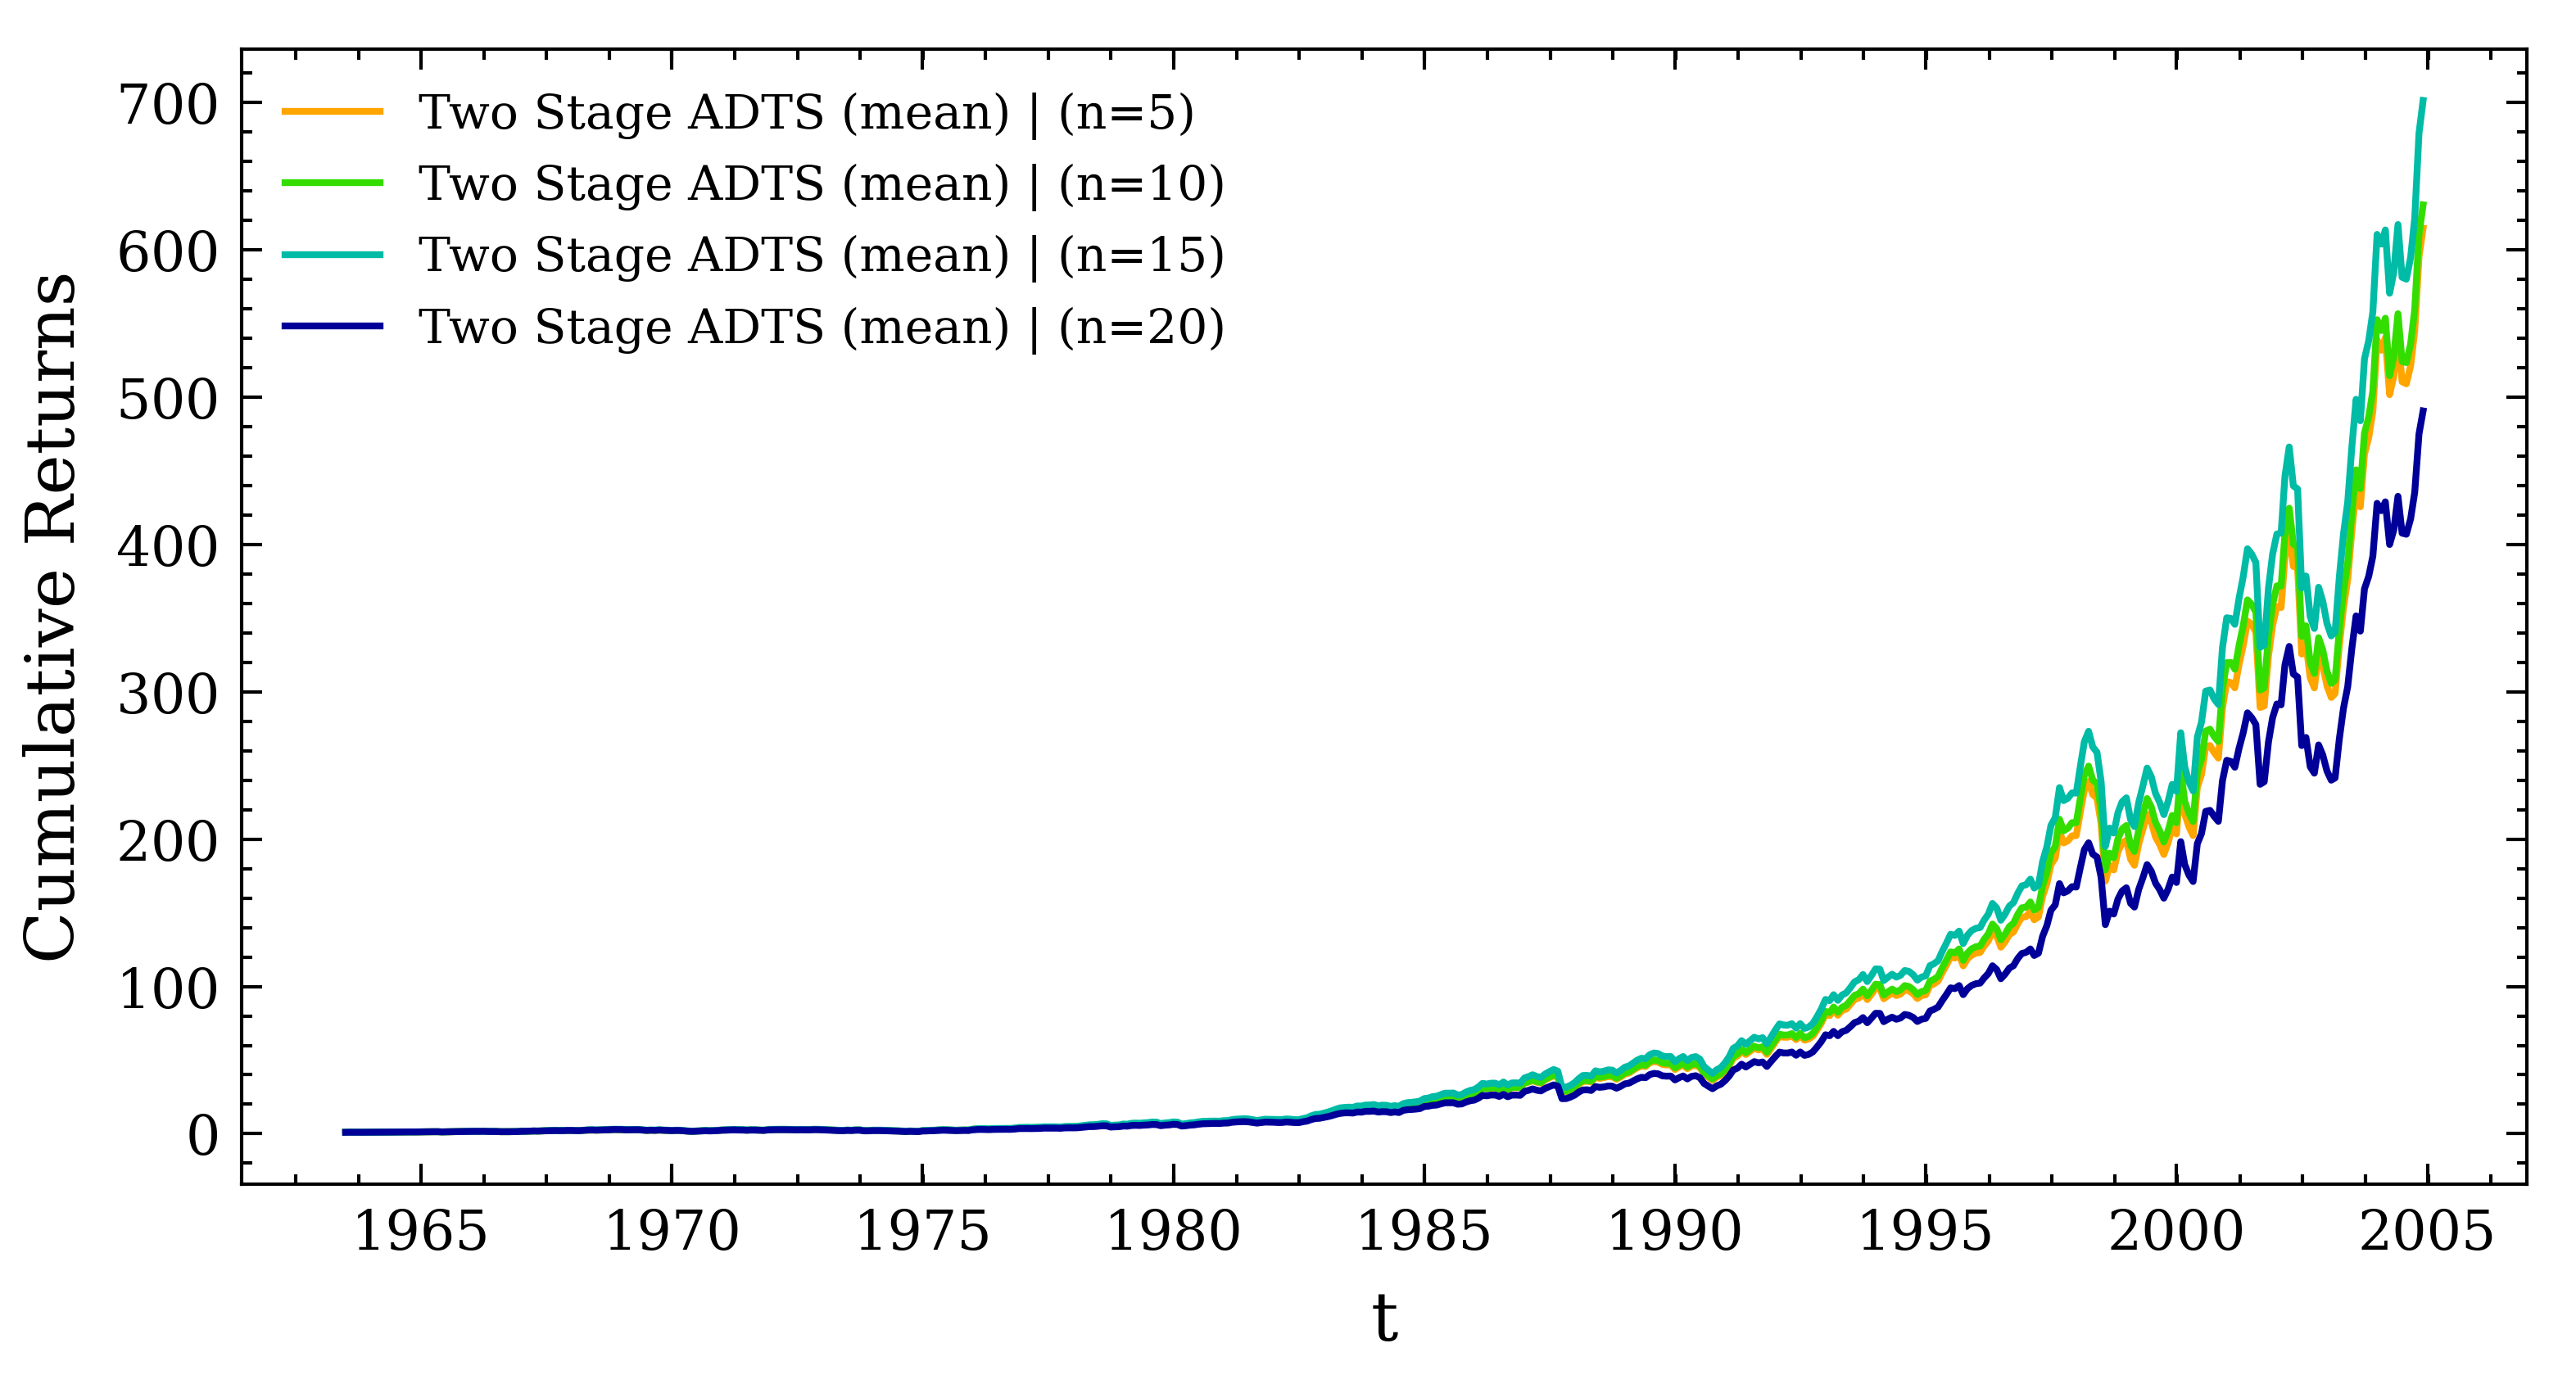

In [75]:
plot_rewards(
    bandit_backtester,
    save_fig=True,
    figure_name="0524_ff100_portfolios.jpg",
    # oracle=df_merge['CMC 200'].values,
    # oracle_name='CMC 200 Index',
    personalized_colors=[c.rgb for c in colors]
)
# ax = plt.gca()
# ax.legend(['a'])
# plt.plot(data[['^CMC200']].cumsum())
# plt.show()

In [60]:
from bandits_lib.portfolio.classical import MarkovitzPortfolio, EqualWeightsPortfolio, RiskParityPortfolio, CAPMPortfolio
from pandas import DataFrame


def calculate_classical_portfolios(portfolio: DataFrame, adjust_frequency: int = 30) -> DataFrame:
    """
    This function calculates the equal weights, risk parity, Markowitz, and Black-Litterman portfolios.
    """
    equal_weights = EqualWeightsPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    risk_parity = RiskParityPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    markowitz = MarkovitzPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    capm = CAPMPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    return pd.DataFrame({
        "Equal Weights": equal_weights,
        "Risk Parity": risk_parity,
        "Markowitz": markowitz,
        "CAPM": capm,
    })

In [61]:
portfolio.tail()

,SMALLLoBM,ME1BM2,ME1BM3,ME1BM4,ME1BM5,ME1BM6,ME1BM7,ME1BM8,ME1BM9,SMALLHiBM,...,BIGLoBM,ME10BM2,ME10BM3,ME10BM4,ME10BM5,ME10BM6,ME10BM7,ME10BM8,ME10BM9,BIGHiBM
date,,,,,,,,,,,,,,,,,,,,,
2004-08-01,-0.011002,-0.014770,-0.030560,-0.005723,-0.001258,0.000839,-0.008537,-0.006898,-0.025546,-0.029490,...,-0.005117,0.003560,0.009401,0.021119,0.023201,-0.008172,0.020514,-0.011696,-0.006950,0.008494
2004-09-01,0.045500,0.048386,0.029392,0.050228,0.035899,0.044204,0.036911,0.028035,0.027232,0.035408,...,-0.007127,0.001380,0.024733,-0.002487,0.020563,0.008393,0.012642,0.006457,0.040579,0.022410
2004-10-01,0.008135,0.009520,-0.012670,0.029069,0.017815,0.025214,0.023254,0.019301,0.008117,0.010906,...,0.013359,0.007827,0.012966,-0.005402,0.008859,0.042197,-0.020791,0.017545,0.022576,0.013275
2004-11-01,0.093441,0.080675,0.093374,0.074657,0.075140,0.074367,0.063831,0.068567,0.055424,0.086860,...,0.020870,0.044202,0.041779,0.039709,0.020798,0.052924,-0.000456,0.057043,0.049235,0.048605
2004-12-01,0.076753,0.065499,0.058963,0.067496,0.058260,0.036880,0.050200,0.054230,0.058772,0.069903,...,0.049521,0.022727,0.012818,0.027818,0.021493,0.034941,0.064752,0.052447,0.017629,0.087275


In [62]:
df_classical = calculate_classical_portfolios(portfolio=portfolio)
# df_classical = df_classical.drop(columns=["Unnamed: 0"], axis=1)

In [63]:
df_classical

,Equal Weights,Risk Parity,Markowitz,CAPM
0,0.000000,0.000000,0.000000,0.000000
1,0.049002,0.049002,0.049002,0.049002
2,-0.019269,-0.019269,-0.019269,-0.019269
3,0.017305,0.017305,0.017305,0.017305
4,-0.010824,-0.010824,-0.010824,-0.010824
...,...,...,...,...
493,-0.004886,-0.003260,0.002612,-0.006346
494,0.039394,0.038085,0.000225,0.040880
495,0.019395,0.019338,0.003497,0.019617
496,0.071884,0.070555,0.007717,0.073438


In [64]:
classical_policies = {}

# df_classical = calculate_classical_portfolios(portfolio=portfolio)
for col in df_classical.columns:
    classical_policies[col] = {
        "mean_reward": df_classical[col].fillna(0.).values
    }
# classical_policies['CMC 200'] = {'mean_reward': df_merge['CMC 200'].values}

In [65]:
unified_policies = bandit_backtester.bandit_policies.copy()
# unified_policies.update(classical_policies)

In [66]:
df_metrics = aggregate_metrics(unified_policies)
# df_metrics.to_csv('backtest_bandit_networks_crypto.csv')
df_metrics

,Cumulative Returns,Sharpe Ratio,Maximum Drawdown,Std. Deviation
Two Stage ADTS (mean) | (n=15),700.369304,0.274615,-128.238435,0.053473
Two Stage ADTS (mean) | (n=10),629.496518,0.273687,-118.937970,0.052712
Two Stage ADTS (mean) | (n=5),613.669929,0.270240,-112.969708,0.053314
Two Stage ADTS (mean) | (n=20),489.627674,0.264835,-90.790008,0.052526


In [67]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcccccc}\n"
table += "\\hline\n"
table += str(" & ".join(list(df_metrics.columns)))+ "\\\n"
table += "\\hline\n"
for i in range(len(df_metrics.index)):
    ticker=df_metrics.index[i]
    results_list = list(df_metrics.loc[ticker, :])
    results_list = [f"${abs(float(r)):.2f}$" if abs(r) >= 1 else f"${abs(float(r)):.3f}$" for r in results_list]
    start_line = f"{ticker} & "
    end_line = "\\\\\n"
    table +=  start_line + " & ".join(results_list) + end_line
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)

\begin{table}[h]
\centering
\begin{tabular}{lcccccc}
\hline
Cumulative Returns & Sharpe Ratio & Maximum Drawdown & Std. Deviation\
\hline
Two Stage ADTS (mean) | (n=15) & $700.37$ & $0.275$ & $128.24$ & $0.053$\\
Two Stage ADTS (mean) | (n=10) & $629.50$ & $0.274$ & $118.94$ & $0.053$\\
Two Stage ADTS (mean) | (n=5) & $613.67$ & $0.270$ & $112.97$ & $0.053$\\
Two Stage ADTS (mean) | (n=20) & $489.63$ & $0.265$ & $90.79$ & $0.053$\\
\hline
\end{tabular}
\caption{Stocks Daily Risks and Returns}
\end{table}



In [68]:
columns = list(portfolio.columns)

corr_dict = {}

for key in bandit_backtester.bandit_policies.keys():
    mean_corr_values = []
    policy_chosen_arms = bandit_backtester.bandit_policies[key]['chosen_superarms']
    for i in range(len(policy_chosen_arms)):
        bandit_arms = policy_chosen_arms[i]['bandit_arms'][-1]
        # 1. Compute the correlation matrix
        corr_matrix = portfolio[[columns[i] for i in bandit_arms]].corr()
        
        # 2. Extract the upper triangle of the correlation matrix, excluding the diagonal
        mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        upper_corr_values = corr_matrix.where(mask)
        
        # 3. Flatten the values and drop NaNs
        mean_correlation = upper_corr_values.stack().mean()
        mean_corr_values.append(mean_correlation)
    corr_dict[key] = mean_corr_values
print(np.mean(mean_corr_values))

0.7468185747815965


In [69]:
# 1. Compute the correlation matrix
corr_matrix = portfolio.corr()

# 2. Extract the upper triangle of the correlation matrix, excluding the diagonal
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_corr_values = corr_matrix.where(mask)

# 3. Flatten the values and drop NaNs
mean_portfolio_correlation = upper_corr_values.stack().mean()

In [70]:
blue = Color("orange", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(bandit_backtester.bandit_policies)))
policies_colors_dict = dict(zip(bandit_backtester.bandit_policies, colors))

In [71]:
[np.mean(corr_dict[key]) for key in corr_dict.keys()]

[np.float64(0.7476550127702847),
 np.float64(0.7352948266061936),
 np.float64(0.7702288764091453),
 np.float64(0.7468185747815965)]

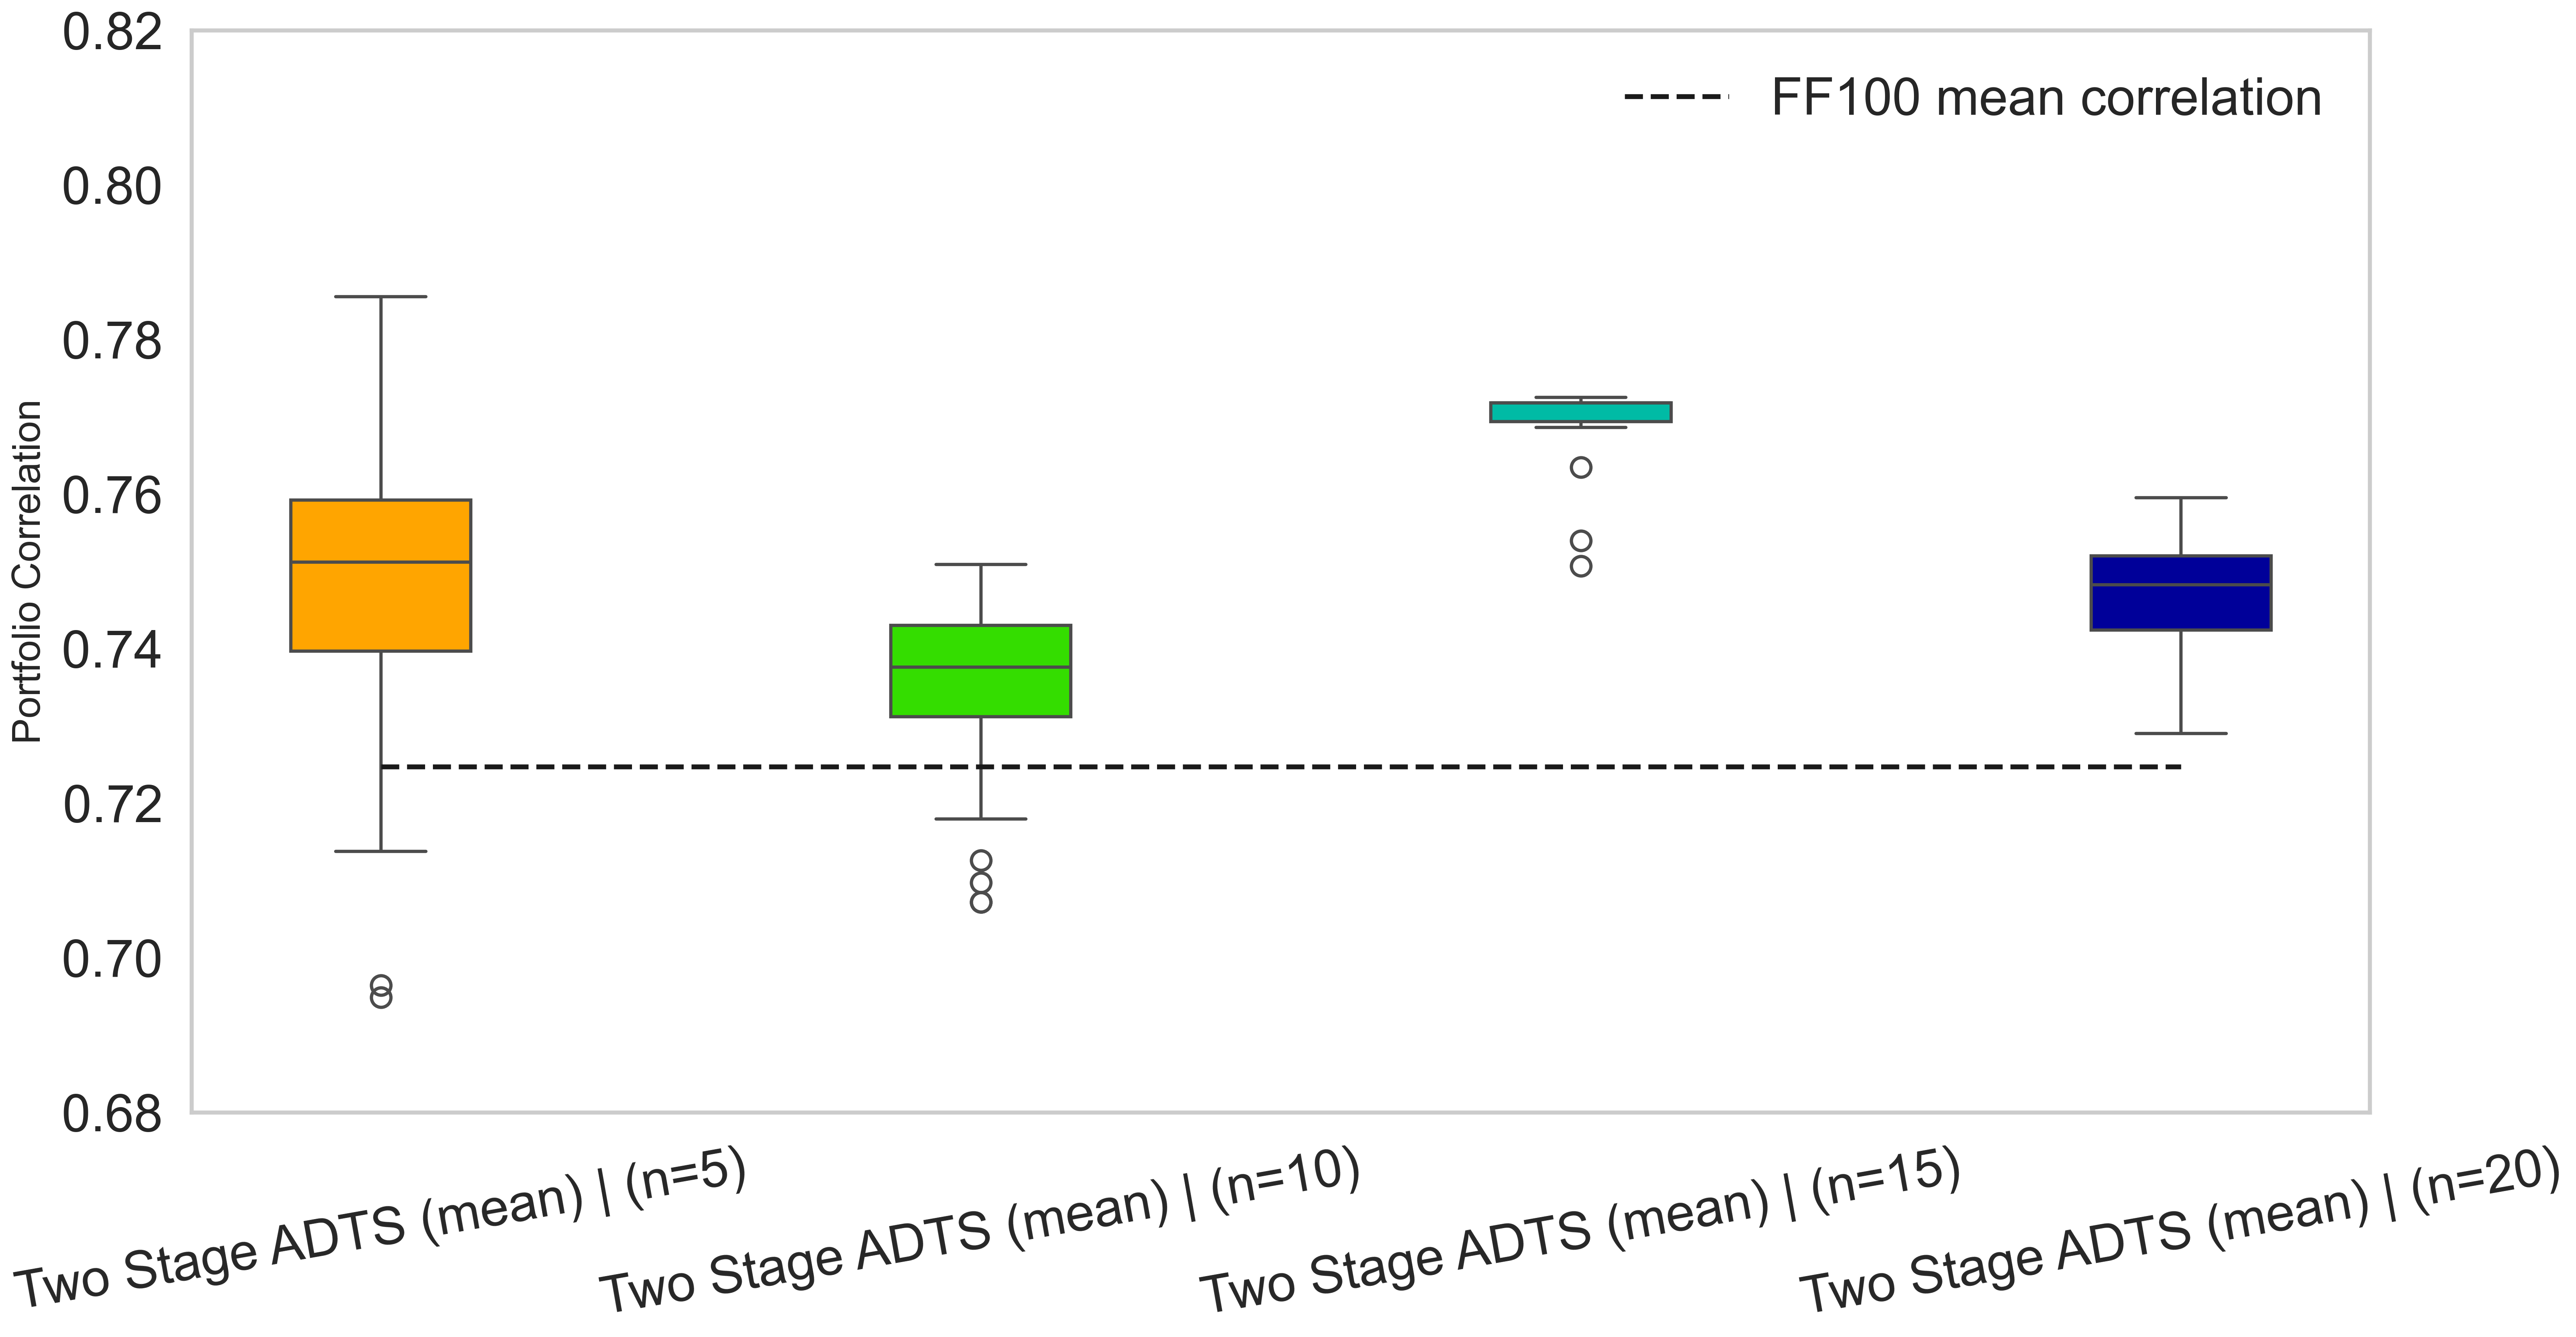

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns



with plt.style.context(['science', 'ieee', 'no-latex']):

    sns.set(style="whitegrid")
    # Create the boxplot
    fig, ax = plt.subplots(figsize=(12, 6))
    boxplot = sns.boxplot(
        data=pd.DataFrame(corr_dict), 
        width=0.3,
        # fontsize=12,
        # palette="Set2", 
        ax=ax,
        # legend=list(corr_dict.keys())
    )
    for patch, policy in zip(ax.patches, corr_dict.keys()):
        patch.set_facecolor(policies_colors_dict[policy].rgb)
#         plt.yscale('log')
    plt.plot([0, 3], [mean_portfolio_correlation, mean_portfolio_correlation], '--k', label='FF100 mean correlation')
    plt.legend(loc='upper right', fontsize=16)
    plt.grid(visible=False)
    ax.tick_params(axis='x', labelsize=16, rotation=10)
    ax.tick_params(axis='y', labelsize=16)
    plt.ylim([0.68, 0.82])
    plt.savefig(f'0524_corr_analysis_ff100.jpg', dpi=600)
    plt.ylabel('Portfolio Correlation', fontsize=12)
    plt.show()